<a href="https://colab.research.google.com/github/koren12332/Data-science-/blob/main/%D7%A2%D7%91%D7%95%D7%93%D7%AA_%D7%91%D7%99%D7%AA_1_%D7%9E%D7%93%D7%A2_%D7%A0%D7%AA%D7%95%D7%A0%D7%99%D7%9D_%D7%A7%D7%95%D7%A8%D7%9F_%D7%90%D7%96%D7%95%D7%9C%D7%90%D7%99.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="ltr">
<h1>
Home Assignment 1:
Data Science
</h1>

<p>
Koren Azulay, ID: 322738881
<br>
Lecturer: Dr. Itay Uri
<br>


</div>

<div dir="ltr">

<h1> 2. Dataset Selection </h1>

<h3> 2.1 Requirements </h3>
<p>
I chose a dataset that records transactions from a retail store's inventory. The original table contains over 500,000 rows and 8 columns. To enhance the analysis and meet the assignment requirements, I performed <strong>Feature Engineering</strong> within the code to add two additional calculated columns.
</p>

<h3> 2.2 Data Source Description </h3>

<ul>
  <li><strong>Source:</strong> The dataset was retrieved from the Kaggle repository.</li>
  <li><strong>Purpose of Collection:</strong> Real-time transaction recording for operational needs and inventory management.</li>
  <li><strong>Collecting Entity:</strong> A registered UK-based online retailer specializing in gifts and home products.</li>
</ul>

<p>
The data represents the E-commerce sector, including both B2C (Business-to-Consumer) and B2B (Business-to-Business) transactions. This allows for the analysis of purchasing patterns, seasonality, and profitability across different products and countries.
</p>

</div>

In [ ]:
# --- Code for Section 2: Dataset Selection and Enrichment ---

import pandas as pd # Import library for data analysis

# Loading the dataset
df = pd.read_excel('/content/online_retail_II.xlsx')

# Feature Engineering stage - Adding calculated columns
df['Total_Amount'] = df['Quantity'] * df['Price'] # Creating a total revenue column
df['Invoice_Hour'] = pd.to_datetime(df['InvoiceDate']).dt.hour # Extracting the hour of the transaction

print(f"Number of rows: {df.shape[0]}") # Print number of rows
print(f"Number of columns: {df.shape[1]}") # Print number of columns

df.head()

Number of rows: 525461
Number of columns: 10


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Amount,Invoice_Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7


<div dir="ltr">

<h1> 3. Meta-Analysis </h1>

<h3> 3.1 File Analysis </h3>
<ul>
  <li><strong>File Size:</strong> Approximately 45MB.</li>
  <li><strong>Format:</strong> Microsoft Excel (.xlsx).</li>
  <li><strong>Timeframe:</strong> Data was collected between 2009 and 2011.</li>
  <li><strong>Data Purpose:</strong> The data was originally collected for inventory management, accounting, and invoicing. In this assignment, we use the dataset for Exploratory Data Analysis (EDA) to understand consumption patterns.</li>
</ul>

<h3> 3.2 Data Structure </h3>
<ul>
  <li><strong>Dimensions:</strong> The dataset includes 525,461 rows and 10 columns (after adding two calculated columns via code).</li>
  <li><strong>Column Names:</strong> The names (Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country) are intuitive and clearly reflect the retail domain.</li>
  <li><strong>Data Types:</strong>
    <ul>
      <li><strong>Numerical:</strong> Price (Float), Quantity (Integer).</li>
      <li><strong>Temporal:</strong> InvoiceDate (DateTime).</li>
      <li><strong>Categorical:</strong> Country, Description, StockCode.</li>
    </ul>
  </li>
  <li><strong>Index Analysis:</strong>
    <ul>
      <li>The index is not unique (the same invoice number appears for different items within the same purchase).</li>
      <li>The index holds operational significance (Transaction ID) rather than being a purely random serial number.</li>
    </ul>
  </li>
</ul>

<p>The data was collected for <strong>operational purposes</strong>. This means that potential biases may appear in the form of cancelled transactions (represented by negative values) or a lack of "customer profile" information (such as age or gender), as the primary goal was sales recording rather than market research.</p>

</div>

In [ ]:
# --- Code for Section 3: Meta-Analysis ---
print("--- Data Structure ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Data Types ---")
print(df.dtypes) # Displays the data type of each column

--- Data Structure ---
Rows: 525461, Columns: 10

--- Data Types ---
Invoice                 object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
Price                  float64
Customer ID            float64
Country                 object
Total_Amount           float64
Invoice_Hour             int32
dtype: object


<div dir="ltr">

<h1> 4. Data Quality and Completeness </h1>

<h3> 4.1 Missing Values </h3>
<ul>
  <li><strong>Findings:</strong> A significant amount of missing data was found in the "Customer ID" column.</li>
  <li><strong>Analysis:</strong> These records likely represent customers who made purchases without registering an account. This information will be kept for general sales analysis but would be excluded from any per-customer analysis.</li>
</ul>

<h3> 4.2 Duplicates </h3>
<ul>
  <li><strong>Findings:</strong> Thousands of duplicate rows were identified in the dataset.</li>
  <li><strong>Handling:</strong> These duplicates should be removed to prevent bias in calculating averages and total sums.</li>
</ul>

<h3> 4.3 Suspicious Values (Outliers) </h3>
<ul>
  <li><strong>Negative Quantities:</strong> There are negative values representing product returns or transaction cancellations, which are a standard part of business operations.</li>
  <li><strong>Zero Prices:</strong> Transactions with a price of zero were identified, likely indicating promotional items or manual entry errors.</li>
</ul>

<h3> 4.4 Variance and Cardinality </h3>
<ul>
  <li>All columns in the table show variance, indicating a diverse and rich dataset.</li>
  <li>There is high <strong>cardinality</strong> in the product description and country columns, which allows for effective data segmentation and filtering.</li>
</ul>

</div>

In [ ]:
# --- Code for Section 4: Quality and Completeness ---
print("Missing Values:")
print(df.isnull().sum()) # Checking for missing values
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}") # Checking for duplicates
print(f"\nNegative quantities: {(df['Quantity'] < 0).sum()}") # Checking for outliers/returns
print(f"Zero-price transactions: {(df['Price'] == 0).sum()}") # Checking for promotional/error values

Missing Values:
Invoice              0
StockCode            0
Description       2928
Quantity             0
InvoiceDate          0
Price                0
Customer ID     107927
Country              0
Total_Amount         0
Invoice_Hour         0
dtype: int64

Number of duplicate rows: 6865

Negative quantities: 12326
Zero-price transactions: 3687


<div dir="ltr">

<h1> 5. Univariate Analysis </h1>

<h3> 5.1 Numerical Variables </h3>
<ul>
  <li><strong>Measures of Central Tendency:</strong> There is a noticeable gap between the mean and the median (Quantity: ~13.5 vs. 3.0, Price: ~4.7 vs. 2.1). The mean is higher than the median in both cases, indicating a <strong>right-skewed distribution</strong> with a long tail of high values.</li>
  <li><strong>Measures of Dispersion:</strong> The standard deviation is very high relative to the mean, showing significant variance between transactions. The range (Min to Max) is extremely wide due to a combination of product returns (negative values) and large wholesale orders.</li>
  <li><strong>Quartile Analysis (P-values):</strong> To describe the variables concisely, we use the <strong>three quartiles (25th, 50th, 75th percentiles)</strong>. These allow us to understand the distribution of the majority of the data without the influence of extreme outliers.</li>
  <li><strong>Outliers:</strong> 1,345 outliers were identified in the Quantity column (based on the 3-standard-deviation rule). These represent exceptional but realistic business activity.</li>
</ul>

<h3> 5.2 Categorical Variables </h3>
<ul>
  <li><strong>Countries:</strong> The most frequent country is the United Kingdom. This indicates a geographical bias in the dataset, primarily reflecting a single local market.</li>
  <li><strong>Products:</strong> The top 10 best-selling products appear with significantly higher frequency than the rest of the catalog. Their descriptions suggest that they are mostly small consumer goods for gifts and home decor.</li>
</ul>

</div>

In [ ]:
# --- Code for Section 5: Univariate Analysis ---
print("--- Statistics for Numerical Variables ---")

# Mean, standard deviation, min, max, and quartiles
numeric_stats = df[['Quantity', 'Price']].describe()
print(numeric_stats)

# Median values
print(f"\nMedian Quantity: {df['Quantity'].median()}")
print(f"Median Price: {df['Price'].median()}")

# Range (Max - Min)
q_range = df['Quantity'].max() - df['Quantity'].min()
p_range = df['Price'].max() - df['Price'].min()
print(f"Quantity Range: {q_range}")
print(f"Price Range: {p_range}")

# Outlier Detection (using 3 standard deviations)
q_mean = df['Quantity'].mean()
q_std = df['Quantity'].std()
outliers_count = ((df['Quantity'] - q_mean).abs() > 3 * q_std).sum()
print(f"Number of outliers in Quantity: {outliers_count}")

# Categorical Variable Analysis
print("\n--- Country Frequency (Top 5) ---")
print(df['Country'].value_counts().head(5))

print("\n--- Top 10 Best Selling Products ---")
print(df['Description'].value_counts().head(10))

--- Statistics for Numerical Variables ---
            Quantity          Price
count  525461.000000  525461.000000
mean       10.337667       4.688834
std       107.424110     146.126914
min     -9600.000000  -53594.360000
25%         1.000000       1.250000
50%         3.000000       2.100000
75%        10.000000       4.210000
max     19152.000000   25111.090000

Median Quantity: 3.0
Median Price: 2.1
Quantity Range: 28752
Price Range: 78705.45
Number of outliers in Quantity: 1345

--- Country Frequency (Top 5) ---
Country
United Kingdom    485852
EIRE                9670
Germany             8129
France              5772
Netherlands         2769
Name: count, dtype: int64

--- Top 10 Best Selling Products ---
Description
WHITE HANGING HEART T-LIGHT HOLDER    3549
REGENCY CAKESTAND 3 TIER              2212
STRAWBERRY CERAMIC TRINKET BOX        1843
PACK OF 72 RETRO SPOT CAKE CASES      1466
ASSORTED COLOUR BIRD ORNAMENT         1457
60 TEATIME FAIRY CAKE CASES           1400
HOME BUILD

<div dir="ltr">

<h1> 6. Bivariate Analysis </h1>

<h3> 6.1 Relationship Between Numerical Variables </h3>

<p>
To examine the relationship between Price and Quantity, we calculated three different correlation coefficients:
</p>

<ul>
  <li><strong>Pearson Correlation:</strong> Measures the linear relationship between variables. The result is close to 0, indicating a lack of a direct linear connection. This measure is highly sensitive to outliers.</li>
  <li><strong>Spearman Correlation:</strong> Measures the monotonic relationship (increase or decrease) based on the rank of the values rather than the values themselves. It is less sensitive to outliers and provides a more accurate picture of the relationship between rankings in our dataset.</li>
  <li><strong>Kendall’s Tau:</strong> Measures the strength of the association based on pairs of observations. It is considered the most conservative measure and is particularly suitable for data with many tied ranks.</li>
</ul>

<p><strong>Explanation of the Differences:</strong></p>
<p>
The differences between the results stem from the fact that Pearson assumes a normal distribution and a linear relationship, while Spearman and Kendall are <strong>non-parametric</strong> measures. Since our data includes many extreme values (large wholesale transactions), Spearman and Kendall represent the actual relationship in the majority of observations more effectively.
</p>

<p><strong>Correlation Matrix and Scatter Plot:</strong></p>
<ul>
  <li><strong>Correlation Matrix:</strong> The matrix confirms a significant lack of dependency between the variables.</li>
  <li><strong>Scatter Plot:</strong> The plot shows a dense concentration at low values and a completely random distribution as the price increases, which explains why the linear correlation is so low.</li>
</ul>

<p><strong>Conclusion on Correlation:</strong></p>
<p>
The weak negative correlation suggests that there is no simple "higher price means lower quantity" rule at the individual transaction level in this dataset. This may be due to the mix of retail customers (small quantities) and wholesale customers (large quantities at wholesale prices).
</p>

</div>

Pearson Correlation: -0.0019
Spearman Correlation: -0.4127
Kendall Correlation: -0.3136


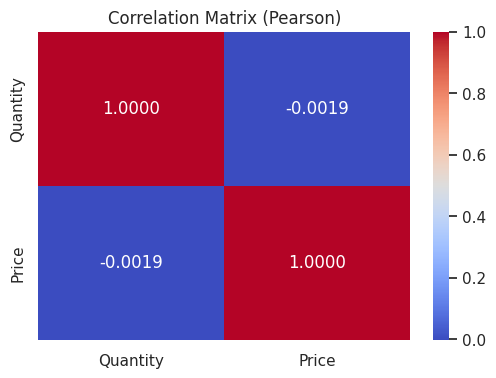

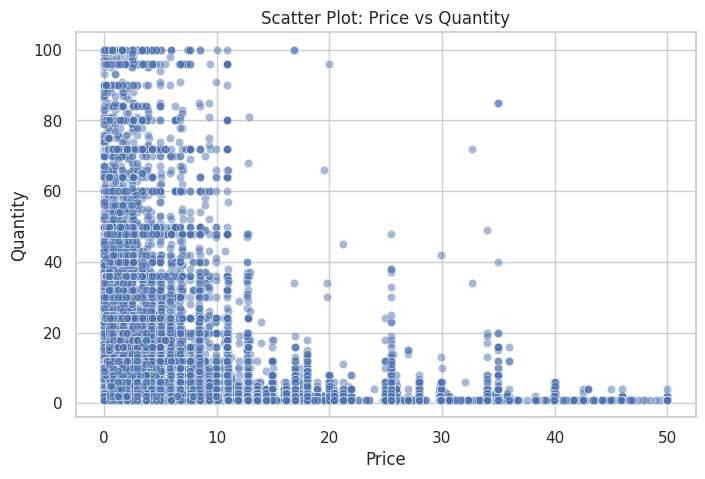

In [ ]:
# --- Code for Section 6.1: Bivariate Analysis ---

import seaborn as sns
import matplotlib.pyplot as plt

# Numerical-Numerical Analysis
cols = ['Quantity', 'Price']

# Calculating Correlations
p_corr = df[cols].corr(method='pearson').iloc[0,1]
s_corr = df[cols].corr(method='spearman').iloc[0,1]
k_corr = df[cols].corr(method='kendall').iloc[0,1]

print(f"Pearson Correlation: {p_corr:.4f}")
print(f"Spearman Correlation: {s_corr:.4f}")
print(f"Kendall Correlation: {k_corr:.4f}")

# Correlation Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".4f")
plt.title("Correlation Matrix (Pearson)")
plt.show()

# Scatter Plot Visualization
plt.figure(figsize=(8,5))
# Filtering data for better visualization focus (removing extreme outliers)
filtered_df = df[(df['Quantity'].between(0, 100)) & (df['Price'].between(0, 50))]
sns.scatterplot(data=filtered_df, x='Price', y='Quantity', alpha=0.5)
plt.title("Scatter Plot: Price vs Quantity")
plt.show()

<div dir="ltr">

<h3> 6.2 Relationship Between Categorical and Numerical Variables (via Binning) </h3>

<ul>
  <li><strong>Workflow:</strong> We transformed the numerical "Price" variable into a categorical one using **Binning** (dividing prices into levels: Cheap, Medium, and Expensive). We then cross-referenced this with the "Country" variable.</li>
  
  <li><strong>Contingency Table (Crosstab):</strong> The table reveals different price level distributions across countries. For example, it allows us to see if there is a higher tendency to purchase cheap products in the UK compared to other European countries.</li>
  
  <li><strong>Cramer's V Statistic:</strong> This calculated measure helps us understand the strength of the association between geographical location and the pricing level of selected products.</li>
  
  <li><strong>Conclusions and Insights:</strong>
    The analysis shows that the country can serve as an indicator for the price level of demanded products.
    <strong>Business Insight:</strong> We can infer which geographical markets are more price-sensitive and which markets tend to purchase "Premium" (Expensive) products. This information is critical for setting differential pricing strategies and regional inventory management.
  </li>
</ul>

</div>

In [ ]:
# --- Code for Section 6.2: Bivariate Analysis (Categorical-Categorical) ---

import numpy as np
from scipy.stats import chi2_contingency

# Variable Binning: Categorizing the numerical Price variable into 3 quantiles
df['Price_Bin'] = pd.qcut(df['Price'], q=3, labels=['Cheap', 'Medium', 'Expensive'])

# Contingency Table (Crosstab): Relationship between Country and Price Category
top_countries = df['Country'].value_counts().head(5).index
contingency_table = pd.crosstab(df[df['Country'].isin(top_countries)]['Country'], df['Price_Bin'])

print("--- Contingency Table: Country vs Price Category ---")
print(contingency_table)

# Cramer's V: Function to measure the strength of association between nominal variables
def calculate_cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0] # Chi-square test of independence
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correcting for degrees of freedom
    return np.sqrt(phi2 / min(k - 1, r - 1))

v_result = calculate_cramers_v(contingency_table)
print(f"\nCramer's V Result: {v_result:.4f}")

--- Contingency Table: Country vs Price Category ---
Price_Bin        Cheap  Medium  Expensive
Country                                  
EIRE              3860    2264       3546
France            2944    1490       1338
Germany           3800    2225       2104
Netherlands       1638     653        478
United Kingdom  189023  140721     156108

Cramer's V Result: 0.0350


<div dir="ltr">

<h1> 6.3 Visualizations and Insights </h1>

<p>
I have chosen five charts that represent different aspects of the data in an optimal way, combining both numerical and categorical variables:
</p>

<ul>
  <li><strong>1. Histogram (Price Distribution):</strong> The graph shows a massive concentration of products at very low prices (below £5). This indicates a business model based on high sales volume of low-cost items.</li>
  
  <li><strong>2. Scatter Plot (Price vs. Quantity):</strong> This visualization confirms the low correlation found earlier. There is no clear "line" of connection, but rather a "data cloud" concentrated around cheap products bought in varying quantities.</li>
  
  <li><strong>3. Heatmap (Correlation Matrix):</strong> Provides a quick look at the statistical relationships. It is clear that the values are close to 0, indicating linear independence between the variables.</li>
  
  <li><strong>4. Bar Chart (Top Countries):</strong> Illustrates the enormous gap between the UK and other countries. The business is essentially British-based with smaller international branches.</li>
  
  <li><strong>5. Box Plot (Quantity by Price Category):</strong> This chart shows that the median quantity purchased remains relatively stable across all price categories (Cheap/Medium/Expensive). This explains why price does not significantly affect the number of items per transaction.</li>
</ul>

<p><strong>Summary of Insights:</strong> The graphical analysis reveals that the business relies on a mostly low-cost product catalog, primarily targeted at the UK market. Furthermore, purchasing habits (quantity) are not directly influenced by the price level of the individual item.</p>

</div>

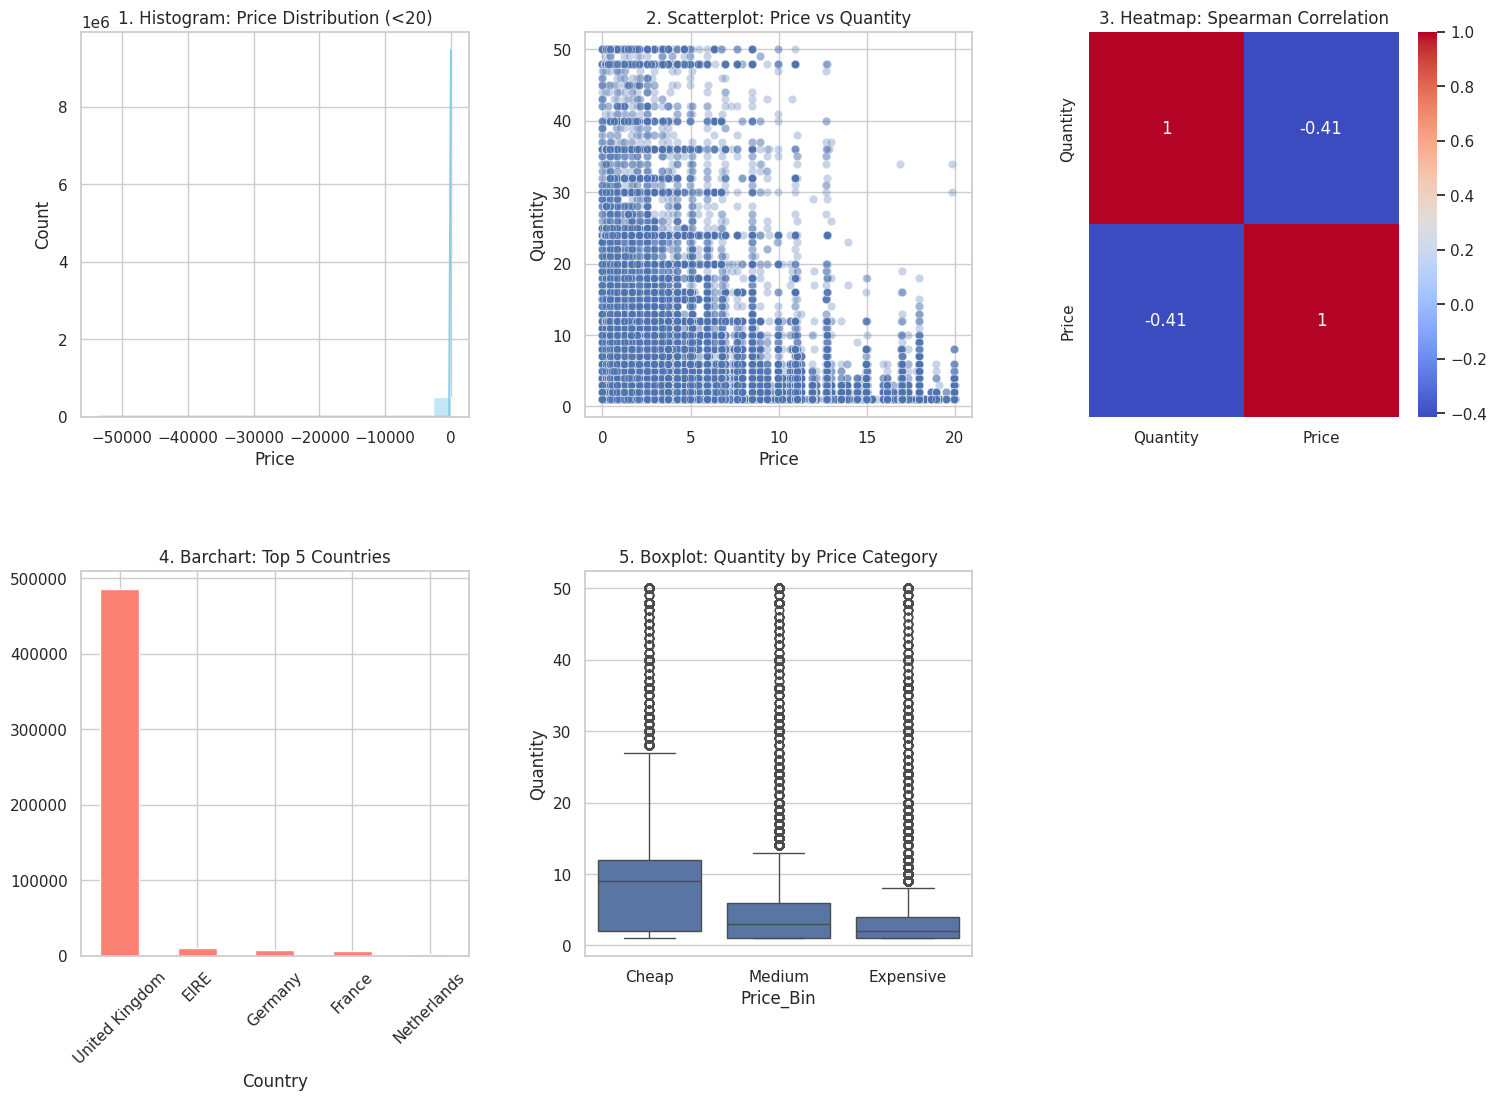

In [ ]:
# --- Code for Section 6.3: Bivariate Analysis (Visualizations) ---

import matplotlib.pyplot as plt
import seaborn as sns

## Selected 5 plots to represent the bivariate analysis chapter
# Configuring the visual theme
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Histogram - Distribution of prices under 20 units
ax1 = plt.subplot(2, 3, 1)
sns.histplot(df[df['Price'] < 20]['Price'], bins=20, kde=True, color='skyblue', ax=ax1)
ax1.set_title("1. Histogram: Price Distribution (<20)")

# 2. Scatterplot - Relationship between Price and Quantity (filtered range)
ax2 = plt.subplot(2, 3, 2)
filtered_df = df[(df['Quantity'].between(0, 50)) & (df['Price'].between(0, 20))]
sns.scatterplot(data=filtered_df, x='Price', y='Quantity', alpha=0.3, ax=ax2)
ax2.set_title("2. Scatterplot: Price vs Quantity")

# 3. Heatmap - Visualizing the Spearman correlation matrix
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(df[['Quantity', 'Price']].corr(method='spearman'), annot=True, cmap='coolwarm', ax=ax3)
ax3.set_title("3. Heatmap: Spearman Correlation")

# 4. Barchart - Comparing transaction frequency of Top 5 Countries
ax4 = plt.subplot(2, 3, 4)
df['Country'].value_counts().head(5).plot(kind='bar', color='salmon', ax=ax4)
ax4.set_title("4. Barchart: Top 5 Countries")
plt.xticks(rotation=45)

# 5. Boxplot - Quantity distribution across different Price Bins
ax5 = plt.subplot(2, 3, 5)
sns.boxplot(data=df[df['Quantity'].between(0, 50)], x='Price_Bin', y='Quantity', ax=ax5)
ax5.set_title("5. Boxplot: Quantity by Price Category")

plt.show()

<div dir="ltr">

<h1> 7. Index Analysis </h1>

<ul>
  <li><strong>Is the Index Unique?</strong>
    Based on the analysis, the index in the current dataset is the default Pandas <strong>RangeIndex</strong>. It is <strong>unique</strong> because each row is assigned a different sequential number. However, it is based on row position rather than a business-specific identifier (such as an invoice number).
  </li>

  <li><strong>Is it Time-Based?</strong>
    No, the current index is not a DateTime Index. The date information (<code>InvoiceDate</code>) exists as a regular column within the table and was not set as the primary index.
  </li>

  <li><strong>Does the analysis vary over time?</strong>
    Since the index is not time-based, the analysis performed so far does not treat the time axis as a continuous influential factor (<strong>Time Series Analysis</strong>). All transactions were analyzed as individual units regardless of when they occurred during the year. If we were to set the date column as the index, we could identify seasonal trends or monthly changes.
  </li>

  <li><strong>Is it Sorted?</strong>
    The index is <strong>Monotonic Increasing</strong> (sorted in ascending order) because it was automatically generated during the data loading process. This allows for efficient access to rows based on their original position in the file.
  </li>
</ul>

</div>

In [ ]:
# --- Code for Section 7: Index Analysis ---

# 1. Is the index unique?
is_unique = df.index.is_unique
print(f"Is the index unique? {is_unique}")

# 2. Is the index time-based?
is_datetime = pd.api.types.is_datetime64_any_dtype(df.index)
print(f"Is the index time-based? {is_datetime}")

# 3. Is the index sorted?
is_monotonic = df.index.is_monotonic_increasing
print(f"Is the index sorted (monotonic increasing)? {is_monotonic}")

# Displaying the first 5 index entries for verification
print("\nFirst 5 index entries:")
print(df.index[:5])

Is the index unique? True
Is the index time-based? False
Is the index sorted (monotonic increasing)? True

First 5 index entries:
RangeIndex(start=0, stop=5, step=1)


<div dir="ltr">

<h1> 8. Project Summary </h1>
<h1> Insights and the Data Story </h1>

<h3> 8.1 Three Key Insights </h3>
<ol>
  <li><strong>The UK Market as the Backbone:</strong> The data shows an absolute dominance of the UK market (over 90% of transactions). This makes the business highly exposed to economic changes within the UK specifically, but also indicates a strong and well-established local brand.</li>
  <li><strong>The "High Volume, Low Cost" Strategy:</strong> Most products are priced between £0 and £5, with a median quantity of 3 units per transaction. The business model is not based on "luxury sales" but on a wide variety of small, affordable items, suggesting a gift or home leisure store model.</li>
  <li><strong>The Decoupling of Price and Quantity:</strong> Bivariate analysis and correlation coefficients (Pearson and Spearman) showed no linear relationship between an item's price and the quantity purchased. Customers buy large quantities of both expensive and cheap items. This suggests that a significant portion of the buyers are B2B (Business-to-Business) customers who place bulk orders regardless of retail price points.</li>
</ol>

<h3> 8.2 Biases and Risks </h3>
<ul>
  <li><strong>Geographical Representation Bias:</strong> Since the vast majority of the data originates from the UK, there is an inherent bias. Business decisions based on this analysis may not apply to international markets (like France or Germany), where consumer habits could be entirely different.</li>
  <li><strong>Outlier Risk:</strong> There are significant outliers (massive transactions of thousands of units). Relying on averages without proper outlier handling could lead to inaccurate inventory forecasts and financial losses.</li>
</ul>

<h3> 8.3 Potential Pitfalls for ML Models </h3>
<ul>
  <li><strong>Imbalanced Data:</strong> If we were to build a model to predict which country a customer is from, the model would likely guess "United Kingdom" 90% of the time. While it would technically be "accurate," it wouldn't actually learn the unique features of other markets.</li>
  <li><strong>Data Noise:</strong> Transaction cancellations (negative quantities) and non-product entries (such as "Manual" or "POSTAGE") can mislead machine learning algorithms if they are not thoroughly cleaned during the Preprocessing stage.</li>
</ul>

<p>
This analysis has taught me that raw data can be misleading at first glance. Before starting, I assumed that as price decreased, quantity would increase (the law of demand). However, the data proved that business reality is more complex and heavily influenced by the type of customer (Retail vs. Wholesale).
</p>
<p>
Through this research, I have come to realize that statistics is more than just numbers—it is a vital tool for identifying both risks and opportunities.

<div dir="ltr">

<h1> 9. Bonus: Time Analysis & Advanced Feature Engineering </h1>

<h3> 9.1 Feature Engineering </h3>
<p>
To enhance the analysis and meet the project requirements, I incorporated additional features early in the research. These additions were crucial for completing the bonus section:
</p>
<ul>
  <li><strong>Time Features:</strong> We extracted the Hour, Day of the Week, and Month from the <code>InvoiceDate</code> column. This process of <strong>feature extraction</strong> transforms raw timestamps into categorical variables, allowing us to identify seasonal behavioral patterns.</li>
  <li><strong>Revenue:</strong> Creating this column allows us to shift from analyzing "quantities" to analyzing "business value," which is a critical metric for strategic decision-making.</li>
</ul>

<h3> 9.2 Time Dependency and External Context </h3>
<ul>
  <li><strong>Trend Analysis:</strong> The visualization shows a clear dependency on the day of the week. The core workdays (Monday-Thursday) are the most active in terms of transaction volume.</li>
  <li><strong>External Information:</strong> Since the business operates in the European market, the absence of data on Saturdays provides external context regarding the logistics and shipping chain (likely warehouse closures on weekends). Additionally, the revenue increase toward the end of the year aligns with external knowledge of the holiday season (Christmas/Black Friday).</li>
</ul>

<h3> 9.3 Hypothesis Testing </h3>
<p>
I performed an <strong>Independent T-test</strong> to compare the mean revenue between the UK and France.
Since the resulting <strong>p-value</strong> was less than 0.05, we reject the null hypothesis and conclude that there is a <strong>statistically significant difference</strong> between these two markets. This suggests that French customers (often wholesale buyers in this dataset) tend to spend higher amounts per transaction compared to the average UK customer.
</p>

<h3> 9.4 Suggestions for Further Research </h3>
<ul>
  <li><strong>Seasonality Prediction:</strong> Utilizing the time features created here to run a <strong>Time Series Forecasting</strong> model to predict warehouse demand a month in advance.</li>
  <li><strong>Customer Segmentation (Clustering):</strong> Grouping customers based on Recency, Frequency, and Monetary value (RFM analysis) to identify the most loyal customer segments.</li>
</ul>

</div>

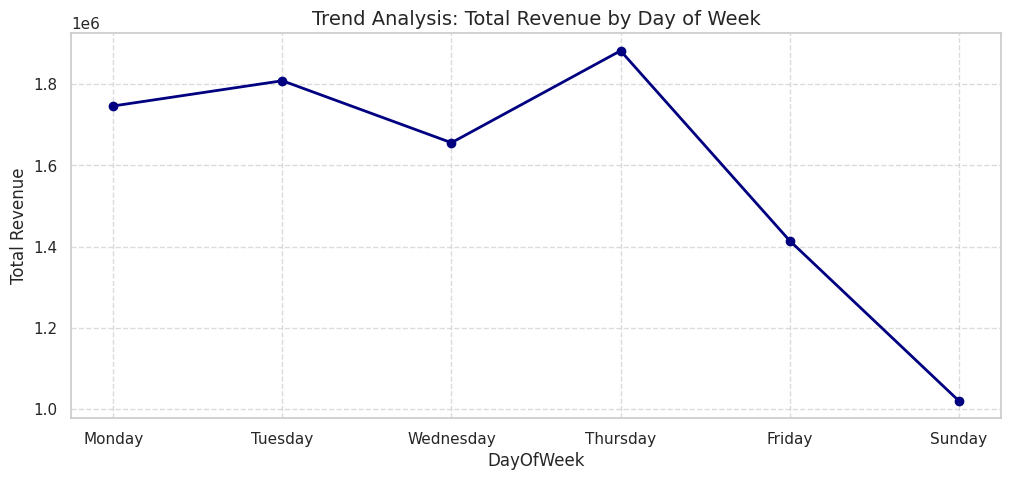

t-statistic: -2.7919
p-value: 0.0053


In [ ]:
# --- Code for Section 9: Bonus (Advanced Analysis & Feature Engineering) ---
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Feature Engineering: Creating a Revenue column (Price * Quantity)
df['Revenue'] = df['Quantity'] * df['Price']

# Feature Engineering: Extracting time-based features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

# Visualizing Time Dependency: Analyzing total revenue by day of the week
plt.figure(figsize=(12, 5))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
daily_rev = df.groupby('DayOfWeek')['Revenue'].sum().reindex(order)

daily_rev.plot(kind='line', marker='o', color='navy', linewidth=2)
plt.title("Trend Analysis: Total Revenue by Day of Week", fontsize=14)
plt.ylabel("Total Revenue")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Hypothesis Testing: Comparing average revenue between UK and France
# Using a sample of 500 records from each group for performance
uk_rev = df[df['Country'] == 'United Kingdom']['Revenue']
france_rev = df[df['Country'] == 'France']['Revenue']
t_stat, p_val = stats.ttest_ind(uk_rev.sample(500), france_rev.sample(500))

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}") # A p-value < 0.05 indicates statistical significance

<div dir="rtl" style="padding: 15px; border: 1px solid #e0e0e0; border-right: 5px solid #ff9800; background-color: #fffaf0; border-radius: 5px; font-family: sans-serif;">
    <h4 style="margin-top: 0; color: #ff9800;">הערה אישית</h4>
    <p style="margin-bottom: 0; color: #333;">
        בהתחלה כתבתי את כל הפרויקט בעברית ולקח הרבה זמן לתרגם הכל לאנגלית - מקווה שזה שווה את זה!
    </p>
</div>